In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/superstore_cleaned.csv')
print("Rows:", len(df))
df.head()

Rows: 9994


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Profit Margin %,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11.25,7


In [2]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.4 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.2 MB 4.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 5.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 5.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 5.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.4 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\raksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


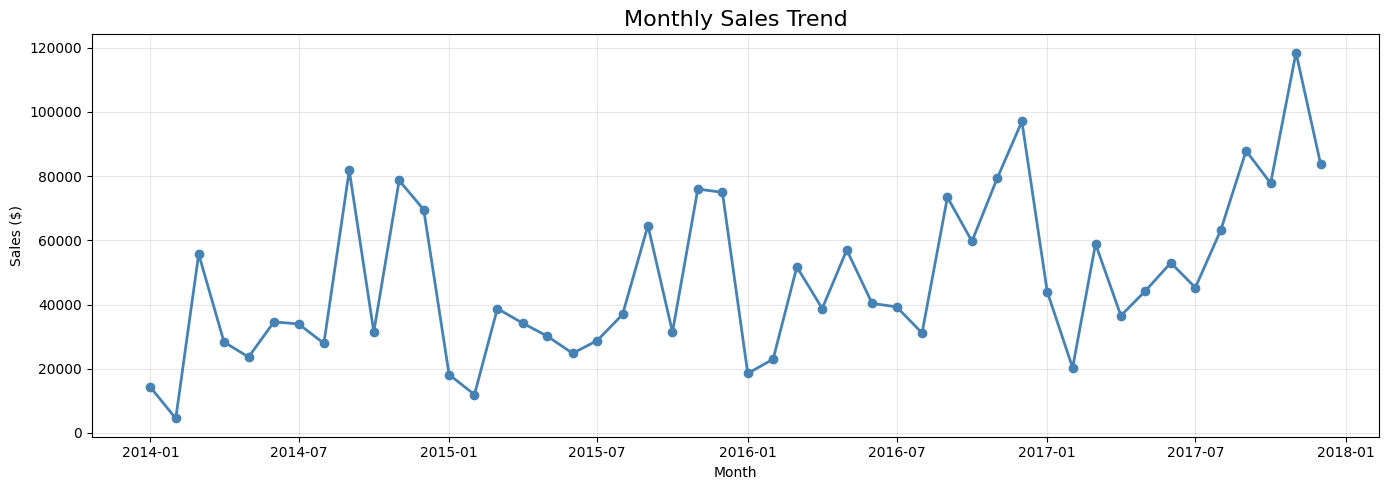

✅ Saved!


In [4]:
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly.rename(columns={
    'Order Year': 'year', 'Order Month': 'month'
})[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Sales'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/01_sales_trend.png')
plt.show()
print("✅ Saved!")

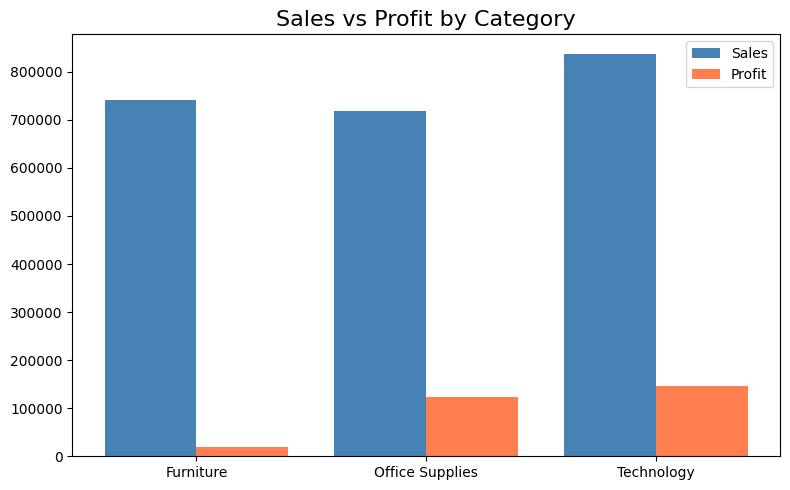

✅ Saved!


In [5]:
cat = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

x = range(len(cat))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, cat['Sales'], width=0.4, label='Sales', color='steelblue')
ax.bar([i+0.4 for i in x], cat['Profit'], width=0.4, label='Profit', color='coral')
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(cat['Category'])
ax.set_title('Sales vs Profit by Category', fontsize=16)
ax.legend()
plt.tight_layout()
plt.savefig('../report/02_category_profit.png')
plt.show()
print("✅ Saved!")

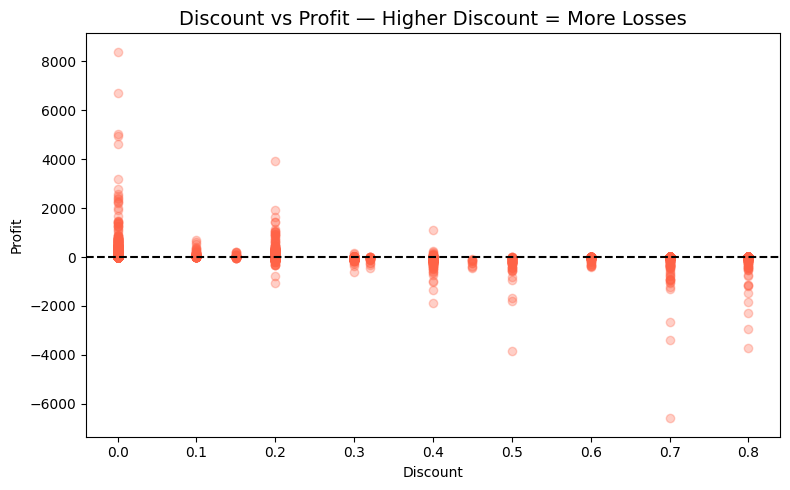

✅ Saved!


In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='tomato')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Discount vs Profit — Higher Discount = More Losses', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.savefig('../report/03_discount_profit.png')
plt.show()
print("✅ Saved!")

C:\Users\raksh\AppData\Local\Temp\ipykernel_30664\2578906654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='Sales', y='State', palette='Blues_r')


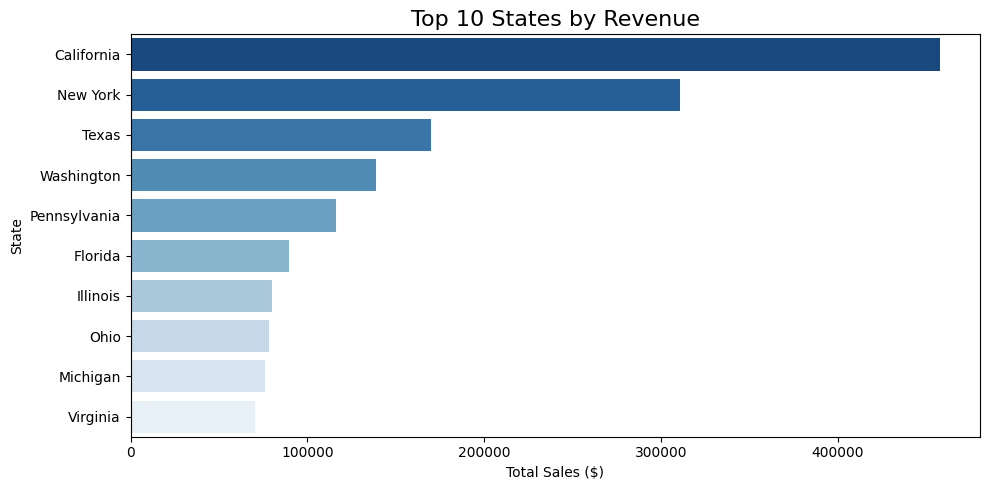

✅ Saved!


In [7]:
state_sales = df.groupby('State')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_sales, x='Sales', y='State', palette='Blues_r')
plt.title('Top 10 States by Revenue', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../report/04_top_states.png')
plt.show()
print("✅ Saved!")

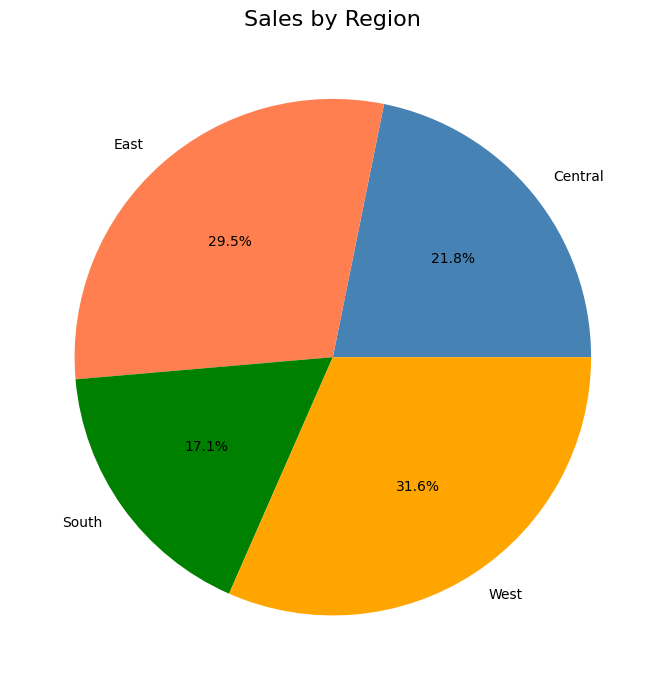

✅ Saved!


In [8]:
region = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(region, labels=region.index, autopct='%1.1f%%', 
        colors=['steelblue','coral','green','orange'])
plt.title('Sales by Region', fontsize=16)
plt.tight_layout()
plt.savefig('../report/05_region_pie.png')
plt.show()
print("✅ Saved!")

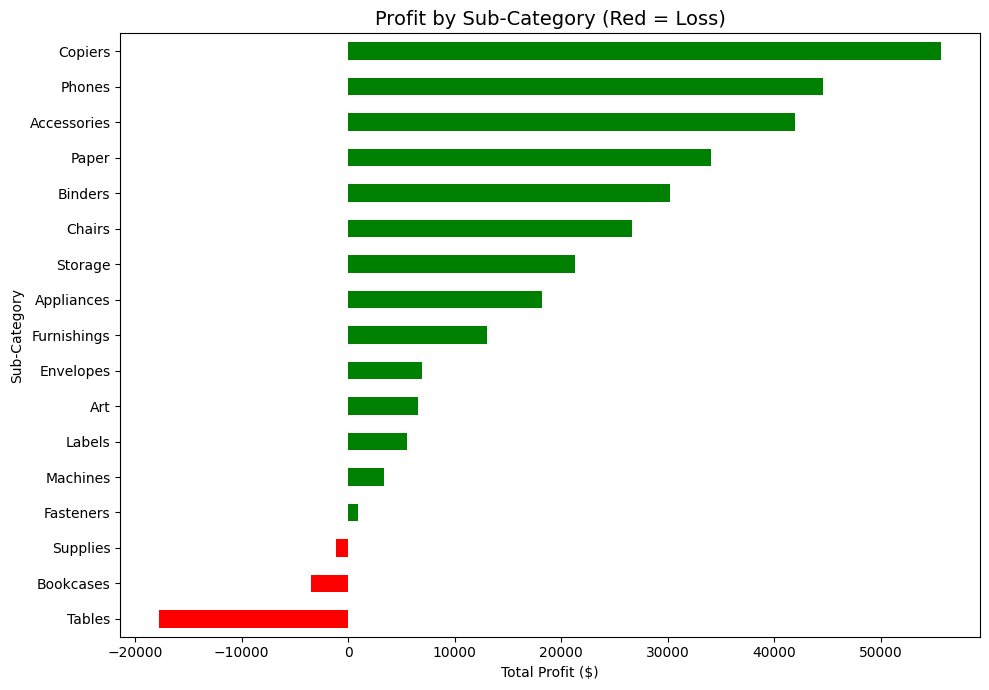

✅ Saved!


In [9]:
subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 7))
colors = ['red' if x < 0 else 'green' for x in subcat]
subcat.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category (Red = Loss)', fontsize=14)
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../report/06_subcategory_profit.png')
plt.show()
print("✅ Saved!")